# Block 1: Imports and Environment Setup

In this block, we import all required Python libraries for data handling, visualization, recommendation modeling, evaluation metrics, statistical testing, and interpretability.

We also configure display settings, warnings, random seeds, and project paths so that the notebook runs in a clean, reproducible, and organized way.

This block does not train any model yet. Its purpose is to prepare the notebook environment for the later steps of the case study.

In [1]:
# Block 1: Imports and Environment Setup

import os
import random
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.preprocessing import MinMaxScaler

from scipy import stats

# -----------------------------
# Basic notebook configuration
# -----------------------------
warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 20)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
random.seed(RANDOM_STATE)

# -----------------------------
# Project paths
# -----------------------------
PROJECT_DIR = Path.cwd()
DATA_DIR = PROJECT_DIR / "data"
FIGURES_DIR = PROJECT_DIR / "figures"

DATA_DIR.mkdir(exist_ok=True)
FIGURES_DIR.mkdir(exist_ok=True)

print("Project directory :", PROJECT_DIR)
print("Data directory    :", DATA_DIR)
print("Figures directory :", FIGURES_DIR)
print("Random state      :", RANDOM_STATE)
print("\nEnvironment setup completed successfully.")

Project directory : c:\Users\dubey\Documents\UC_GitLab\Spring_2026_BI_Sem_2\Case Study Part 2 - Comprehensive Model Evaluation and Interpretability
Data directory    : c:\Users\dubey\Documents\UC_GitLab\Spring_2026_BI_Sem_2\Case Study Part 2 - Comprehensive Model Evaluation and Interpretability\data
Figures directory : c:\Users\dubey\Documents\UC_GitLab\Spring_2026_BI_Sem_2\Case Study Part 2 - Comprehensive Model Evaluation and Interpretability\figures
Random state      : 42

Environment setup completed successfully.


# Block 2: Data Loading and Initial Inspection

In this block, we load the e-commerce recommendation dataset from the local `data` folder and perform an initial inspection.

The objective is to understand:
- how many rows and columns are present
- what the column names are
- the data types of each field
- whether there are missing values
- a small sample of records

This step is important because recommendation datasets may vary in structure, and we need to confirm the available user, item, rating, and metadata fields before preprocessing.

In [2]:
# Block 2: Data Loading and Initial Inspection

# List files in data directory
data_files = list(DATA_DIR.glob("*"))

print("Files found in data folder:")
for file in data_files:
    print("-", file.name)

# Keep only common tabular file types
candidate_files = [
    f for f in data_files
    if f.suffix.lower() in [".csv", ".tsv", ".txt", ".xlsx"]
]

if not candidate_files:
    raise FileNotFoundError(
        "No supported dataset file found in the data folder. "
        "Please place the Kaggle dataset file inside the data directory."
    )

# Use the first matching file
DATA_FILE = candidate_files[0]
print(f"\nSelected data file: {DATA_FILE.name}")

# Load file based on extension
if DATA_FILE.suffix.lower() == ".csv":
    df = pd.read_csv(DATA_FILE)
elif DATA_FILE.suffix.lower() == ".tsv":
    df = pd.read_csv(DATA_FILE, sep="\t")
elif DATA_FILE.suffix.lower() == ".txt":
    df = pd.read_csv(DATA_FILE, sep=None, engine="python")
elif DATA_FILE.suffix.lower() == ".xlsx":
    df = pd.read_excel(DATA_FILE)
else:
    raise ValueError(f"Unsupported file format: {DATA_FILE.suffix}")

print("\nDataset loaded successfully.")
print(f"Shape of dataset: {df.shape}")

print("\nColumn names:")
print(df.columns.tolist())

print("\nData types:")
print(df.dtypes)

print("\nFirst 5 rows:")
display(df.head())

print("\nMissing values by column:")
display(df.isnull().sum().sort_values(ascending=False))

Files found in data folder:
- ratings_Beauty.csv

Selected data file: ratings_Beauty.csv

Dataset loaded successfully.
Shape of dataset: (2023070, 4)

Column names:
['UserId', 'ProductId', 'Rating', 'Timestamp']

Data types:
UserId        object
ProductId     object
Rating       float64
Timestamp      int64
dtype: object

First 5 rows:


,UserId,ProductId,Rating,Timestamp
0,A39HTATAQ9V7YF,0205616461,5.0,1369699200
1,A3JM6GV9MNOF9X,0558925278,3.0,1355443200
2,A1Z513UWSAAO0F,0558925278,5.0,1404691200
3,A1WMRR494NWEWV,0733001998,4.0,1382572800
4,A3IAAVS479H7M7,0737104473,1.0,1274227200



Missing values by column:


UserId       0
ProductId    0
Rating       0
Timestamp    0
dtype: int64

# Block 3: Data Cleaning, Type Validation, and Basic Dataset Profiling

In this block, we prepare a clean working version of the recommendation dataset.

The main goals are:
- verify that the dataset has no duplicate interaction records
- confirm rating values and their distribution
- convert Unix timestamps into readable datetime format
- measure the number of unique users and products
- compute basic sparsity-related statistics for the recommendation problem

This step is important because recommendation datasets are usually very sparse, and understanding the number of users, items, and interactions helps guide model design and evaluation strategy.

In [3]:
# Block 3: Data Cleaning, Type Validation, and Basic Dataset Profiling

# Create a clean working copy
ratings_df = df.copy()

print("Initial shape:", ratings_df.shape)

# Remove exact duplicate rows if any
duplicate_count = ratings_df.duplicated().sum()
print("Duplicate rows found:", duplicate_count)

if duplicate_count > 0:
    ratings_df = ratings_df.drop_duplicates().reset_index(drop=True)

print("Shape after duplicate removal:", ratings_df.shape)

# Convert timestamp to datetime
ratings_df["InteractionTime"] = pd.to_datetime(ratings_df["Timestamp"], unit="s")

# Basic value checks
print("\nRating summary statistics:")
display(ratings_df["Rating"].describe())

print("\nUnique rating values:")
print(sorted(ratings_df["Rating"].unique()))

# Core profiling
n_users = ratings_df["UserId"].nunique()
n_items = ratings_df["ProductId"].nunique()
n_interactions = len(ratings_df)

# Matrix sparsity estimate
possible_interactions = n_users * n_items
sparsity = 1 - (n_interactions / possible_interactions)

print("\nDataset profiling summary:")
print(f"Number of unique users       : {n_users:,}")
print(f"Number of unique products    : {n_items:,}")
print(f"Number of interactions       : {n_interactions:,}")
print(f"Possible user-item pairs     : {possible_interactions:,}")
print(f"Estimated matrix sparsity    : {sparsity:.6f}")

# Interactions per user and per item
user_interaction_counts = ratings_df.groupby("UserId").size()
item_interaction_counts = ratings_df.groupby("ProductId").size()

print("\nInteractions per user:")
display(user_interaction_counts.describe())

print("\nInteractions per product:")
display(item_interaction_counts.describe())

print("\nDate range of interactions:")
print("Start:", ratings_df["InteractionTime"].min())
print("End  :", ratings_df["InteractionTime"].max())

print("\nFirst 5 rows of cleaned working dataset:")
display(ratings_df.head())

Initial shape: (2023070, 4)
Duplicate rows found: 0
Shape after duplicate removal: (2023070, 4)

Rating summary statistics:


count    2.023070e+06
mean     4.149036e+00
std      1.311505e+00
min      1.000000e+00
25%      4.000000e+00
50%      5.000000e+00
75%      5.000000e+00
max      5.000000e+00
Name: Rating, dtype: float64


Unique rating values:
[np.float64(1.0), np.float64(2.0), np.float64(3.0), np.float64(4.0), np.float64(5.0)]

Dataset profiling summary:
Number of unique users       : 1,210,271
Number of unique products    : 249,274
Number of interactions       : 2,023,070
Possible user-item pairs     : 301,689,093,254
Estimated matrix sparsity    : 0.999993

Interactions per user:


count    1.210271e+06
mean     1.671584e+00
std      2.531884e+00
min      1.000000e+00
25%      1.000000e+00
50%      1.000000e+00
75%      2.000000e+00
max      3.890000e+02
dtype: float64


Interactions per product:


count    249274.000000
mean          8.115848
std          36.064113
min           1.000000
25%           1.000000
50%           2.000000
75%           5.000000
max        7533.000000
dtype: float64


Date range of interactions:
Start: 1998-10-19 00:00:00
End  : 2014-07-23 00:00:00

First 5 rows of cleaned working dataset:


,UserId,ProductId,Rating,Timestamp,InteractionTime
0,A39HTATAQ9V7YF,0205616461,5.0,1369699200,2013-05-28
1,A3JM6GV9MNOF9X,0558925278,3.0,1355443200,2012-12-14
2,A1Z513UWSAAO0F,0558925278,5.0,1404691200,2014-07-07
3,A1WMRR494NWEWV,0733001998,4.0,1382572800,2013-10-24
4,A3IAAVS479H7M7,0737104473,1.0,1274227200,2010-05-19


# Block 4: Sparse User-Item Filtering and Temporal Train-Validation-Test Split

In this block, we reduce the extreme sparsity of the dataset by filtering out users and products with very few interactions.

This is necessary because recommendation algorithms such as collaborative filtering require enough interaction history to learn meaningful patterns.

The filtering strategy used here is:
- keep users with at least 5 interactions
- keep products with at least 5 interactions

After filtering, the dataset is sorted by interaction time and split into:
- training set
- validation set
- test set

A temporal split is used instead of a random split in order to better simulate real-world recommendation settings and avoid leakage from future interactions into the training data.

In [4]:
# Block 4: Sparse User-Item Filtering and Temporal Train-Validation-Test Split

# Minimum interaction thresholds
MIN_USER_INTERACTIONS = 5
MIN_ITEM_INTERACTIONS = 5

print("Original dataset shape:", ratings_df.shape)

# Filter users
user_counts = ratings_df["UserId"].value_counts()
eligible_users = user_counts[user_counts >= MIN_USER_INTERACTIONS].index

filtered_df = ratings_df[ratings_df["UserId"].isin(eligible_users)].copy()

# Filter items
item_counts = filtered_df["ProductId"].value_counts()
eligible_items = item_counts[item_counts >= MIN_ITEM_INTERACTIONS].index

filtered_df = filtered_df[filtered_df["ProductId"].isin(eligible_items)].copy()

# Re-check users after item filtering
user_counts_final = filtered_df["UserId"].value_counts()
eligible_users_final = user_counts_final[user_counts_final >= MIN_USER_INTERACTIONS].index
filtered_df = filtered_df[filtered_df["UserId"].isin(eligible_users_final)].copy()

# Re-check items after user filtering
item_counts_final = filtered_df["ProductId"].value_counts()
eligible_items_final = item_counts_final[item_counts_final >= MIN_ITEM_INTERACTIONS].index
filtered_df = filtered_df[filtered_df["ProductId"].isin(eligible_items_final)].copy()

filtered_df = filtered_df.sort_values("InteractionTime").reset_index(drop=True)

print("\nFiltering thresholds:")
print(f"Minimum user interactions : {MIN_USER_INTERACTIONS}")
print(f"Minimum item interactions : {MIN_ITEM_INTERACTIONS}")

print("\nFiltered dataset shape:", filtered_df.shape)
print("Unique users after filtering   :", filtered_df["UserId"].nunique())
print("Unique products after filtering:", filtered_df["ProductId"].nunique())

# Temporal split: 70% train, 15% validation, 15% test
n_total = len(filtered_df)
train_end = int(n_total * 0.70)
val_end = int(n_total * 0.85)

train_df = filtered_df.iloc[:train_end].copy()
val_df = filtered_df.iloc[train_end:val_end].copy()
test_df = filtered_df.iloc[val_end:].copy()

print("\nTemporal split sizes:")
print(f"Train set      : {train_df.shape}")
print(f"Validation set : {val_df.shape}")
print(f"Test set       : {test_df.shape}")

print("\nDate ranges by split:")
print("Train      :", train_df["InteractionTime"].min(), "to", train_df["InteractionTime"].max())
print("Validation :", val_df["InteractionTime"].min(), "to", val_df["InteractionTime"].max())
print("Test       :", test_df["InteractionTime"].min(), "to", test_df["InteractionTime"].max())

# Coverage checks
train_users = set(train_df["UserId"].unique())
train_items = set(train_df["ProductId"].unique())

val_new_users = (~val_df["UserId"].isin(train_users)).sum()
val_new_items = (~val_df["ProductId"].isin(train_items)).sum()

test_new_users = (~test_df["UserId"].isin(train_users)).sum()
test_new_items = (~test_df["ProductId"].isin(train_items)).sum()

print("\nCold-start checks relative to training set:")
print(f"Validation rows with new users  : {val_new_users:,}")
print(f"Validation rows with new items  : {val_new_items:,}")
print(f"Test rows with new users        : {test_new_users:,}")
print(f"Test rows with new items        : {test_new_items:,}")

print("\nFirst 5 rows of filtered dataset:")
display(filtered_df.head())

Original dataset shape: (2023070, 5)

Filtering thresholds:
Minimum user interactions : 5
Minimum item interactions : 5

Filtered dataset shape: (224229, 5)
Unique users after filtering   : 27499
Unique products after filtering: 13727

Temporal split sizes:
Train set      : (156960, 5)
Validation set : (33634, 5)
Test set       : (33635, 5)

Date ranges by split:
Train      : 2002-06-12 00:00:00 to 2013-12-27 00:00:00
Validation : 2013-12-27 00:00:00 to 2014-04-08 00:00:00
Test       : 2014-04-08 00:00:00 to 2014-07-23 00:00:00

Cold-start checks relative to training set:
Validation rows with new users  : 9,978
Validation rows with new items  : 4,582
Test rows with new users        : 13,850
Test rows with new items        : 10,136

First 5 rows of filtered dataset:


,UserId,ProductId,Rating,Timestamp,InteractionTime
0,A281NPSIMI1C2R,B0000535UX,5.0,1023840000,2002-06-12
1,A281NPSIMI1C2R,B0000535UN,5.0,1024185600,2002-06-16
2,A281NPSIMI1C2R,B0000535UM,5.0,1024185600,2002-06-16
3,AWIF8AR75LL9L,B000065DK4,5.0,1036627200,2002-11-07
4,A281NPSIMI1C2R,B000052Y33,5.0,1052611200,2003-05-11


# Block 5: Exploratory Analysis of Ratings, User Activity, and Product Popularity

In this block, we perform exploratory data analysis on the filtered recommendation dataset.

The purpose is to understand:
- how ratings are distributed
- whether user activity is balanced or heavily skewed
- whether product popularity is concentrated among a few items
- how interaction volume changes over time

This analysis is important because recommendation models are strongly influenced by data imbalance, popularity concentration, and temporal usage patterns.

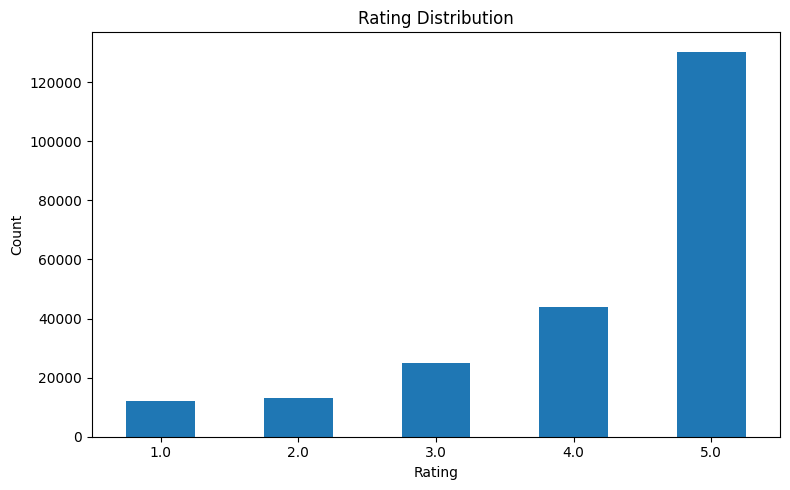

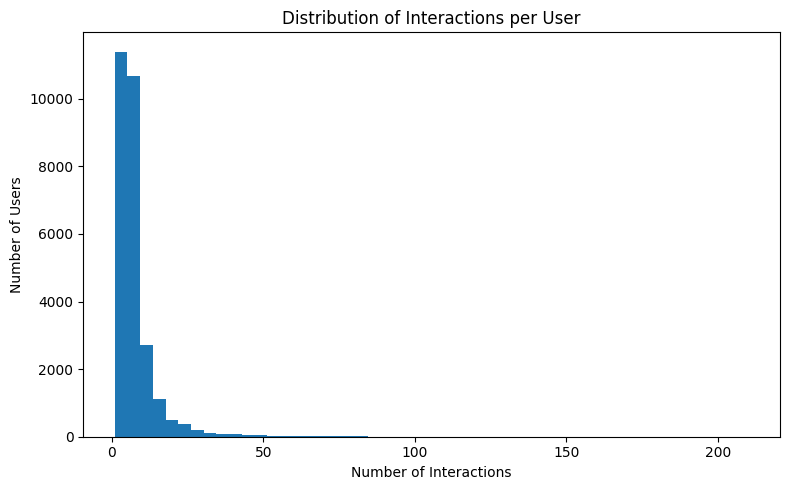

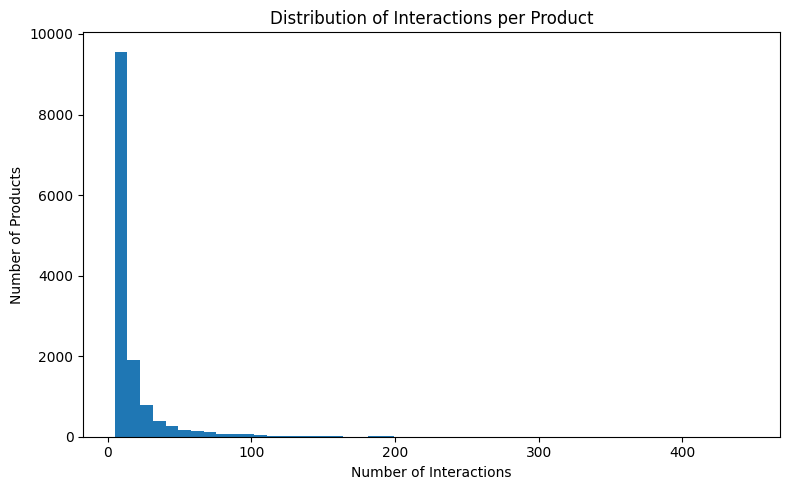

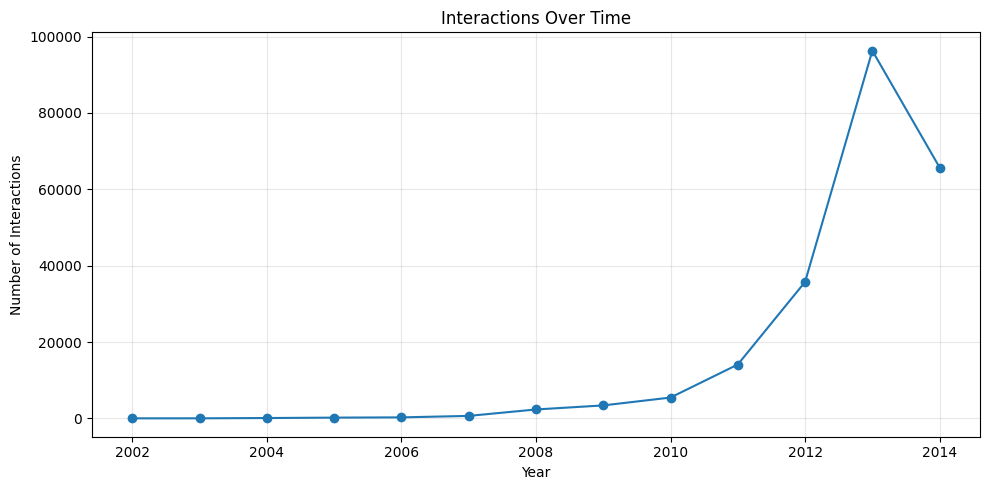

Filtered rating distribution:


Rating
1.0     12125
2.0     13033
3.0     24849
4.0     43879
5.0    130343
Name: count, dtype: int64


Filtered interactions per user summary:


count    27499.000000
mean         8.154078
std          7.772064
min          1.000000
25%          5.000000
50%          6.000000
75%          8.000000
max        210.000000
dtype: float64


Filtered interactions per product summary:


count    13727.000000
mean        16.334887
std         23.682500
min          5.000000
25%          6.000000
50%          9.000000
75%         16.000000
max        446.000000
dtype: float64


Top 10 most frequently rated products:


ProductId
B004OHQR1Q    446
B0043OYFKU    441
B000ZMBSPE    436
B0069FDR96    405
B00150LT40    357
B003V265QW    344
B000142FVW    340
B006L1DNWY    330
B007BLN17K    319
B008U1Q4DI    319
Name: count, dtype: int64


Interactions by year:


InteractionTime
2002        4
2003        9
2004       85
2005      192
2006      258
2007      642
2008     2328
2009     3390
2010     5451
2011    14106
2012    35743
2013    96308
2014    65713
dtype: int64

In [5]:
# Block 5: Exploratory Analysis of Ratings, User Activity, and Product Popularity

# Create summary series
filtered_user_counts = filtered_df.groupby("UserId").size()
filtered_item_counts = filtered_df.groupby("ProductId").size()
interactions_by_year = filtered_df.groupby(filtered_df["InteractionTime"].dt.year).size()

# Create figure 1: rating distribution
plt.figure(figsize=(8, 5))
filtered_df["Rating"].value_counts().sort_index().plot(kind="bar")
plt.title("Rating Distribution")
plt.xlabel("Rating")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "rating_distribution.png", dpi=300)
plt.show()

# Create figure 2: user activity distribution
plt.figure(figsize=(8, 5))
plt.hist(filtered_user_counts, bins=50)
plt.title("Distribution of Interactions per User")
plt.xlabel("Number of Interactions")
plt.ylabel("Number of Users")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "user_interaction_distribution.png", dpi=300)
plt.show()

# Create figure 3: product popularity distribution
plt.figure(figsize=(8, 5))
plt.hist(filtered_item_counts, bins=50)
plt.title("Distribution of Interactions per Product")
plt.xlabel("Number of Interactions")
plt.ylabel("Number of Products")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "product_interaction_distribution.png", dpi=300)
plt.show()

# Create figure 4: yearly interaction trend
plt.figure(figsize=(10, 5))
interactions_by_year.plot(marker="o")
plt.title("Interactions Over Time")
plt.xlabel("Year")
plt.ylabel("Number of Interactions")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "interactions_over_time.png", dpi=300)
plt.show()

# Print descriptive summaries
print("Filtered rating distribution:")
display(filtered_df["Rating"].value_counts().sort_index())

print("\nFiltered interactions per user summary:")
display(filtered_user_counts.describe())

print("\nFiltered interactions per product summary:")
display(filtered_item_counts.describe())

print("\nTop 10 most frequently rated products:")
display(filtered_df["ProductId"].value_counts().head(10))

print("\nInteractions by year:")
display(interactions_by_year)

# Block 6: Baseline Recommender Construction

In this block, we construct a simple baseline recommendation model.

The baseline predicts ratings using:
- the average rating of each product in the training set
- the global average rating as a fallback for unseen products

This baseline is important because it provides a reference point for evaluating whether more advanced recommendation models such as collaborative filtering, content-based filtering, and hybrid approaches truly add value beyond simple popularity-driven behavior.

In [6]:
# Block 6: Baseline Recommender Construction

# Global mean rating from training data
global_mean_rating = train_df["Rating"].mean()

# Item mean ratings from training data
item_mean_ratings = train_df.groupby("ProductId")["Rating"].mean()

def predict_baseline(dataframe, item_means, global_mean):
    """
    Predict ratings using item average rating.
    If item is unseen in training, use global mean rating.
    """
    return dataframe["ProductId"].map(item_means).fillna(global_mean)

# Generate predictions
train_df = train_df.copy()
val_df = val_df.copy()
test_df = test_df.copy()

train_df["Baseline_Pred"] = predict_baseline(train_df, item_mean_ratings, global_mean_rating)
val_df["Baseline_Pred"] = predict_baseline(val_df, item_mean_ratings, global_mean_rating)
test_df["Baseline_Pred"] = predict_baseline(test_df, item_mean_ratings, global_mean_rating)

# Compute RMSE and MAE
baseline_train_rmse = np.sqrt(mean_squared_error(train_df["Rating"], train_df["Baseline_Pred"]))
baseline_val_rmse = np.sqrt(mean_squared_error(val_df["Rating"], val_df["Baseline_Pred"]))
baseline_test_rmse = np.sqrt(mean_squared_error(test_df["Rating"], test_df["Baseline_Pred"]))

baseline_train_mae = mean_absolute_error(train_df["Rating"], train_df["Baseline_Pred"])
baseline_val_mae = mean_absolute_error(val_df["Rating"], val_df["Baseline_Pred"])
baseline_test_mae = mean_absolute_error(test_df["Rating"], test_df["Baseline_Pred"])

print("Baseline model summary")
print(f"Global mean rating: {global_mean_rating:.4f}")
print(f"Number of item mean ratings learned: {len(item_mean_ratings):,}")

print("\nBaseline performance:")
print(f"Train RMSE : {baseline_train_rmse:.4f}")
print(f"Validation RMSE : {baseline_val_rmse:.4f}")
print(f"Test RMSE : {baseline_test_rmse:.4f}")

print(f"\nTrain MAE : {baseline_train_mae:.4f}")
print(f"Validation MAE : {baseline_val_mae:.4f}")
print(f"Test MAE : {baseline_test_mae:.4f}")

print("\nSample baseline predictions on validation data:")
display(
    val_df[["UserId", "ProductId", "Rating", "Baseline_Pred"]]
    .head(10)
)

Baseline model summary
Global mean rating: 4.1839
Number of item mean ratings learned: 13,082

Baseline performance:
Train RMSE : 1.0704
Validation RMSE : 1.2180
Test RMSE : 1.1861

Train MAE : 0.8219
Validation MAE : 0.9202
Test MAE : 0.9085

Sample baseline predictions on validation data:


,UserId,ProductId,Rating,Baseline_Pred
156960,AEYZG3EZKHOSJ,B005Y6F4WO,5.0,4.663462
156961,A222W9OFZ65R5U,B003GDK6F2,5.0,4.344828
156962,A30IP88QK3YUIO,B000PLUZL8,1.0,4.203540
156963,A2AJ85T9EYTMUO,B000L596FE,5.0,4.523256
156964,A3KO6JEVS1FJ8X,B0076XERS0,5.0,4.500000
156965,A3EBZDT05P5RXZ,B004RRC7YY,5.0,5.000000
156966,A1O49KX1QJ0VFL,B0007CXX82,5.0,4.377778
156967,AIQWQDZDTPQIO,B0007CXWWY,5.0,4.000000
156968,A39PE92UTLIR9X,B00076X0BS,5.0,4.000000
156969,A30X9M0J5WOVAS,B00AYARK2C,5.0,4.846154


# Block 7: Collaborative Filtering Model

In this block, we implement an item-based collaborative filtering recommender.

The main idea is:
- products that receive similar rating patterns from users are considered similar
- if a user has rated items similar to a target product, those ratings can help estimate the user's likely rating for the target product

This method is more personalized than the baseline model because predictions depend not only on product popularity, but also on the user's own historical preferences.

To make the computation manageable, we build the collaborative filtering model using the training data and use cosine similarity between item vectors. For cases where a prediction cannot be reliably computed, we fall back to the baseline item-average prediction.

In [7]:
# Block 7: Collaborative Filtering Model

from sklearn.metrics.pairwise import cosine_similarity

# ----------------------------------------
# Build user-item matrix from training data
# ----------------------------------------
user_item_matrix = train_df.pivot_table(
    index="UserId",
    columns="ProductId",
    values="Rating"
)

# Fill missing values with 0 for cosine similarity
item_user_matrix_filled = user_item_matrix.fillna(0).T

# Compute item-item cosine similarity
item_similarity_matrix = pd.DataFrame(
    cosine_similarity(item_user_matrix_filled),
    index=item_user_matrix_filled.index,
    columns=item_user_matrix_filled.index
)

print("User-item matrix shape:", user_item_matrix.shape)
print("Item similarity matrix shape:", item_similarity_matrix.shape)

# ----------------------------------------
# Store user rating history from training set
# ----------------------------------------
user_ratings_dict = (
    train_df.groupby("UserId")[["ProductId", "Rating"]]
    .apply(lambda x: list(zip(x["ProductId"], x["Rating"])))
    .to_dict()
)

def predict_cf_rating(user_id, product_id, user_history_dict, similarity_df, fallback_pred, top_n=10):
    """
    Predict a user's rating for a product using item-based collaborative filtering.
    Falls back to baseline prediction if the user/product is unseen or no similar items are available.
    """
    # Cold-start checks
    if user_id not in user_history_dict:
        return fallback_pred

    if product_id not in similarity_df.index:
        return fallback_pred

    rated_items = user_history_dict[user_id]
    weighted_scores = []
    similarity_weights = []

    for rated_product, rated_rating in rated_items:
        if rated_product == product_id:
            continue
        if rated_product not in similarity_df.columns:
            continue

        sim_score = similarity_df.loc[product_id, rated_product]

        if sim_score > 0:
            weighted_scores.append(sim_score * rated_rating)
            similarity_weights.append(sim_score)

    if len(similarity_weights) == 0:
        return fallback_pred

    pred = np.sum(weighted_scores) / np.sum(similarity_weights)
    return pred

def generate_cf_predictions(dataframe, fallback_column_name="Baseline_Pred", top_n=10):
    preds = []
    for _, row in dataframe.iterrows():
        pred = predict_cf_rating(
            user_id=row["UserId"],
            product_id=row["ProductId"],
            user_history_dict=user_ratings_dict,
            similarity_df=item_similarity_matrix,
            fallback_pred=row[fallback_column_name],
            top_n=top_n
        )
        preds.append(pred)
    return preds

# ----------------------------------------
# Generate predictions
# ----------------------------------------
val_df["CF_Pred"] = generate_cf_predictions(val_df)
test_df["CF_Pred"] = generate_cf_predictions(test_df)

# Clip predictions to rating scale
val_df["CF_Pred"] = val_df["CF_Pred"].clip(1.0, 5.0)
test_df["CF_Pred"] = test_df["CF_Pred"].clip(1.0, 5.0)

# ----------------------------------------
# Evaluate collaborative filtering model
# ----------------------------------------
cf_val_rmse = np.sqrt(mean_squared_error(val_df["Rating"], val_df["CF_Pred"]))
cf_test_rmse = np.sqrt(mean_squared_error(test_df["Rating"], test_df["CF_Pred"]))

cf_val_mae = mean_absolute_error(val_df["Rating"], val_df["CF_Pred"])
cf_test_mae = mean_absolute_error(test_df["Rating"], test_df["CF_Pred"])

print("\nCollaborative Filtering Performance:")
print(f"Validation RMSE : {cf_val_rmse:.4f}")
print(f"Test RMSE       : {cf_test_rmse:.4f}")
print(f"Validation MAE  : {cf_val_mae:.4f}")
print(f"Test MAE        : {cf_test_mae:.4f}")

print("\nSample CF predictions on validation data:")
display(
    val_df[["UserId", "ProductId", "Rating", "Baseline_Pred", "CF_Pred"]]
    .head(10)
)

User-item matrix shape: (24080, 13082)
Item similarity matrix shape: (13082, 13082)

Collaborative Filtering Performance:
Validation RMSE : 1.2522
Test RMSE       : 1.2084
Validation MAE  : 0.9183
Test MAE        : 0.9085

Sample CF predictions on validation data:


,UserId,ProductId,Rating,Baseline_Pred,CF_Pred
156960,AEYZG3EZKHOSJ,B005Y6F4WO,5.0,4.663462,4.663462
156961,A222W9OFZ65R5U,B003GDK6F2,5.0,4.344828,4.344828
156962,A30IP88QK3YUIO,B000PLUZL8,1.0,4.203540,4.000000
156963,A2AJ85T9EYTMUO,B000L596FE,5.0,4.523256,5.000000
156964,A3KO6JEVS1FJ8X,B0076XERS0,5.0,4.500000,4.500000
156965,A3EBZDT05P5RXZ,B004RRC7YY,5.0,5.000000,5.000000
156966,A1O49KX1QJ0VFL,B0007CXX82,5.0,4.377778,4.377778
156967,AIQWQDZDTPQIO,B0007CXWWY,5.0,4.000000,4.000000
156968,A39PE92UTLIR9X,B00076X0BS,5.0,4.000000,4.000000
156969,A30X9M0J5WOVAS,B00AYARK2C,5.0,4.846154,4.846154


# Block 8: Content-Based Style Recommendation Model

In this block, we construct a content-based style recommendation model using item-level features derived from the training data.

Because the current dataset does not contain rich product metadata such as titles, descriptions, or categories, we create item representations using available behavioral features including:
- average item rating
- rating count
- rating variance
- recency information derived from timestamps

These item profiles are then normalized and compared using cosine similarity. Recommendations are generated by matching the target product to other behaviorally similar products that the user has previously rated.

This approach is useful because it does not rely entirely on collaborative overlap and can provide an alternative perspective when pure collaborative filtering performs weakly.

In [8]:
# Block 8: Content-Based Style Recommendation Model

# ----------------------------------------
# Build item feature table from training data
# ----------------------------------------
item_feature_df = train_df.groupby("ProductId").agg(
    ItemMeanRating=("Rating", "mean"),
    ItemRatingCount=("Rating", "count"),
    ItemRatingStd=("Rating", "std"),
    FirstInteraction=("Timestamp", "min"),
    LastInteraction=("Timestamp", "max")
).reset_index()

# Fill missing std for items with one rating
item_feature_df["ItemRatingStd"] = item_feature_df["ItemRatingStd"].fillna(0)

# Recency-style feature: interaction span
item_feature_df["InteractionSpan"] = (
    item_feature_df["LastInteraction"] - item_feature_df["FirstInteraction"]
)

# Keep only numeric item features for similarity
item_feature_cols = [
    "ItemMeanRating",
    "ItemRatingCount",
    "ItemRatingStd",
    "FirstInteraction",
    "LastInteraction",
    "InteractionSpan"
]

# Normalize features
scaler = MinMaxScaler()
item_feature_matrix = scaler.fit_transform(item_feature_df[item_feature_cols])

# Compute item-item similarity
content_similarity_matrix = pd.DataFrame(
    cosine_similarity(item_feature_matrix),
    index=item_feature_df["ProductId"],
    columns=item_feature_df["ProductId"]
)

print("Item feature table shape:", item_feature_df.shape)
print("Content similarity matrix shape:", content_similarity_matrix.shape)

# ----------------------------------------
# Reuse user history from training set
# ----------------------------------------
def predict_content_rating(user_id, product_id, user_history_dict, similarity_df, fallback_pred):
    """
    Predict a user's rating for a product using content-style item similarity.
    Falls back to baseline prediction if user/product is unseen or no similar items exist.
    """
    if user_id not in user_history_dict:
        return fallback_pred

    if product_id not in similarity_df.index:
        return fallback_pred

    rated_items = user_history_dict[user_id]
    weighted_scores = []
    similarity_weights = []

    for rated_product, rated_rating in rated_items:
        if rated_product == product_id:
            continue
        if rated_product not in similarity_df.columns:
            continue

        sim_score = similarity_df.loc[product_id, rated_product]

        if sim_score > 0:
            weighted_scores.append(sim_score * rated_rating)
            similarity_weights.append(sim_score)

    if len(similarity_weights) == 0:
        return fallback_pred

    pred = np.sum(weighted_scores) / np.sum(similarity_weights)
    return pred

def generate_content_predictions(dataframe, fallback_column_name="Baseline_Pred"):
    preds = []
    for _, row in dataframe.iterrows():
        pred = predict_content_rating(
            user_id=row["UserId"],
            product_id=row["ProductId"],
            user_history_dict=user_ratings_dict,
            similarity_df=content_similarity_matrix,
            fallback_pred=row[fallback_column_name]
        )
        preds.append(pred)
    return preds

# ----------------------------------------
# Generate predictions
# ----------------------------------------
val_df["Content_Pred"] = generate_content_predictions(val_df)
test_df["Content_Pred"] = generate_content_predictions(test_df)

# Clip predictions to rating scale
val_df["Content_Pred"] = val_df["Content_Pred"].clip(1.0, 5.0)
test_df["Content_Pred"] = test_df["Content_Pred"].clip(1.0, 5.0)

# ----------------------------------------
# Evaluate content-based model
# ----------------------------------------
content_val_rmse = np.sqrt(mean_squared_error(val_df["Rating"], val_df["Content_Pred"]))
content_test_rmse = np.sqrt(mean_squared_error(test_df["Rating"], test_df["Content_Pred"]))

content_val_mae = mean_absolute_error(val_df["Rating"], val_df["Content_Pred"])
content_test_mae = mean_absolute_error(test_df["Rating"], test_df["Content_Pred"])

print("\nContent-Based Style Model Performance:")
print(f"Validation RMSE : {content_val_rmse:.4f}")
print(f"Test RMSE       : {content_test_rmse:.4f}")
print(f"Validation MAE  : {content_val_mae:.4f}")
print(f"Test MAE        : {content_test_mae:.4f}")

print("\nSample content-based predictions on validation data:")
display(
    val_df[["UserId", "ProductId", "Rating", "Baseline_Pred", "Content_Pred"]]
    .head(10)
)

Item feature table shape: (13082, 7)
Content similarity matrix shape: (13082, 13082)

Content-Based Style Model Performance:
Validation RMSE : 1.2781
Test RMSE       : 1.2261
Validation MAE  : 0.9195
Test MAE        : 0.9073

Sample content-based predictions on validation data:


,UserId,ProductId,Rating,Baseline_Pred,Content_Pred
156960,AEYZG3EZKHOSJ,B005Y6F4WO,5.0,4.663462,4.663462
156961,A222W9OFZ65R5U,B003GDK6F2,5.0,4.344828,4.619078
156962,A30IP88QK3YUIO,B000PLUZL8,1.0,4.203540,4.285307
156963,A2AJ85T9EYTMUO,B000L596FE,5.0,4.523256,4.603184
156964,A3KO6JEVS1FJ8X,B0076XERS0,5.0,4.500000,4.743490
156965,A3EBZDT05P5RXZ,B004RRC7YY,5.0,5.000000,3.328161
156966,A1O49KX1QJ0VFL,B0007CXX82,5.0,4.377778,5.000000
156967,AIQWQDZDTPQIO,B0007CXWWY,5.0,4.000000,4.747114
156968,A39PE92UTLIR9X,B00076X0BS,5.0,4.000000,5.000000
156969,A30X9M0J5WOVAS,B00AYARK2C,5.0,4.846154,5.000000


# Block 9: Hybrid Recommendation Model

In this block, we combine the predictions from the baseline, collaborative filtering, and content-based models into a hybrid recommender.

The motivation for a hybrid model is that different recommendation approaches have different strengths:
- the baseline model is stable and robust
- collaborative filtering captures behavioral similarity across items
- content-based modeling provides an alternative similarity perspective from item-level features

By combining these models, the hybrid recommender aims to improve overall performance and reduce the weaknesses of any single approach.

In [9]:
# Block 9: Hybrid Recommendation Model

# Weighted hybrid prediction
# We give the strongest weight to baseline because it has performed best so far.
BASELINE_WEIGHT = 0.50
CF_WEIGHT = 0.30
CONTENT_WEIGHT = 0.20

val_df["Hybrid_Pred"] = (
    BASELINE_WEIGHT * val_df["Baseline_Pred"] +
    CF_WEIGHT * val_df["CF_Pred"] +
    CONTENT_WEIGHT * val_df["Content_Pred"]
)

test_df["Hybrid_Pred"] = (
    BASELINE_WEIGHT * test_df["Baseline_Pred"] +
    CF_WEIGHT * test_df["CF_Pred"] +
    CONTENT_WEIGHT * test_df["Content_Pred"]
)

# Clip to valid rating range
val_df["Hybrid_Pred"] = val_df["Hybrid_Pred"].clip(1.0, 5.0)
test_df["Hybrid_Pred"] = test_df["Hybrid_Pred"].clip(1.0, 5.0)

# Evaluate hybrid model
hybrid_val_rmse = np.sqrt(mean_squared_error(val_df["Rating"], val_df["Hybrid_Pred"]))
hybrid_test_rmse = np.sqrt(mean_squared_error(test_df["Rating"], test_df["Hybrid_Pred"]))

hybrid_val_mae = mean_absolute_error(val_df["Rating"], val_df["Hybrid_Pred"])
hybrid_test_mae = mean_absolute_error(test_df["Rating"], test_df["Hybrid_Pred"])

print("Hybrid model weights:")
print(f"Baseline weight : {BASELINE_WEIGHT}")
print(f"CF weight       : {CF_WEIGHT}")
print(f"Content weight  : {CONTENT_WEIGHT}")

print("\nHybrid Model Performance:")
print(f"Validation RMSE : {hybrid_val_rmse:.4f}")
print(f"Test RMSE       : {hybrid_test_rmse:.4f}")
print(f"Validation MAE  : {hybrid_val_mae:.4f}")
print(f"Test MAE        : {hybrid_test_mae:.4f}")

print("\nSample hybrid predictions on validation data:")
display(
    val_df[[
        "UserId", "ProductId", "Rating",
        "Baseline_Pred", "CF_Pred", "Content_Pred", "Hybrid_Pred"
    ]].head(10)
)

Hybrid model weights:
Baseline weight : 0.5
CF weight       : 0.3
Content weight  : 0.2

Hybrid Model Performance:
Validation RMSE : 1.1892
Test RMSE       : 1.1642
Validation MAE  : 0.9034
Test MAE        : 0.8979

Sample hybrid predictions on validation data:


,UserId,ProductId,Rating,Baseline_Pred,CF_Pred,Content_Pred,Hybrid_Pred
156960,AEYZG3EZKHOSJ,B005Y6F4WO,5.0,4.663462,4.663462,4.663462,4.663462
156961,A222W9OFZ65R5U,B003GDK6F2,5.0,4.344828,4.344828,4.619078,4.399678
156962,A30IP88QK3YUIO,B000PLUZL8,1.0,4.203540,4.000000,4.285307,4.158831
156963,A2AJ85T9EYTMUO,B000L596FE,5.0,4.523256,5.000000,4.603184,4.682265
156964,A3KO6JEVS1FJ8X,B0076XERS0,5.0,4.500000,4.500000,4.743490,4.548698
156965,A3EBZDT05P5RXZ,B004RRC7YY,5.0,5.000000,5.000000,3.328161,4.665632
156966,A1O49KX1QJ0VFL,B0007CXX82,5.0,4.377778,4.377778,5.000000,4.502222
156967,AIQWQDZDTPQIO,B0007CXWWY,5.0,4.000000,4.000000,4.747114,4.149423
156968,A39PE92UTLIR9X,B00076X0BS,5.0,4.000000,4.000000,5.000000,4.200000
156969,A30X9M0J5WOVAS,B00AYARK2C,5.0,4.846154,4.846154,5.000000,4.876923


# Block 10: Quantitative Evaluation with Ranking Metrics

In this block, we evaluate the recommendation model using ranking-based metrics.

While RMSE and MAE measure rating prediction error, ranking metrics are more aligned with real recommendation system behavior because users typically see only the top few recommended items.

The metrics computed in this block are:
- Precision@K
- Recall@K
- NDCG@K

These metrics help assess whether the most highly ranked recommendations are actually relevant to the user.

In [10]:
# Block 10: Quantitative Evaluation with Ranking Metrics

K = 5
RELEVANCE_THRESHOLD = 4.0  # ratings >= 4 are treated as relevant

# Use hybrid predictions on the test set
ranking_df = test_df[["UserId", "ProductId", "Rating", "Hybrid_Pred"]].copy()

# Keep only users with at least K candidate items in test set
user_test_counts = ranking_df["UserId"].value_counts()
eligible_test_users = user_test_counts[user_test_counts >= K].index
ranking_df = ranking_df[ranking_df["UserId"].isin(eligible_test_users)].copy()

def precision_at_k(actual_ratings, predicted_scores, k=5, threshold=4.0):
    top_k_idx = np.argsort(predicted_scores)[::-1][:k]
    top_k_relevant = np.array(actual_ratings)[top_k_idx] >= threshold
    return np.mean(top_k_relevant)

def recall_at_k(actual_ratings, predicted_scores, k=5, threshold=4.0):
    actual_ratings = np.array(actual_ratings)
    predicted_scores = np.array(predicted_scores)

    relevant_items = actual_ratings >= threshold
    n_relevant = relevant_items.sum()

    if n_relevant == 0:
        return np.nan

    top_k_idx = np.argsort(predicted_scores)[::-1][:k]
    top_k_relevant = actual_ratings[top_k_idx] >= threshold
    return top_k_relevant.sum() / n_relevant

def ndcg_at_k(actual_ratings, predicted_scores, k=5):
    actual_ratings = np.array(actual_ratings)
    predicted_scores = np.array(predicted_scores)

    top_k_idx = np.argsort(predicted_scores)[::-1][:k]
    gains = actual_ratings[top_k_idx]
    discounts = np.log2(np.arange(2, len(gains) + 2))
    dcg = np.sum((2**gains - 1) / discounts)

    ideal_idx = np.argsort(actual_ratings)[::-1][:k]
    ideal_gains = actual_ratings[ideal_idx]
    ideal_discounts = np.log2(np.arange(2, len(ideal_gains) + 2))
    idcg = np.sum((2**ideal_gains - 1) / ideal_discounts)

    if idcg == 0:
        return np.nan

    return dcg / idcg

user_metrics = []

for user_id, group in ranking_df.groupby("UserId"):
    actual = group["Rating"].values
    preds = group["Hybrid_Pred"].values

    p_at_k = precision_at_k(actual, preds, k=K, threshold=RELEVANCE_THRESHOLD)
    r_at_k = recall_at_k(actual, preds, k=K, threshold=RELEVANCE_THRESHOLD)
    n_at_k = ndcg_at_k(actual, preds, k=K)

    user_metrics.append({
        "UserId": user_id,
        "Precision@K": p_at_k,
        "Recall@K": r_at_k,
        "NDCG@K": n_at_k
    })

ranking_metrics_df = pd.DataFrame(user_metrics)

avg_precision_k = ranking_metrics_df["Precision@K"].mean()
avg_recall_k = ranking_metrics_df["Recall@K"].mean()
avg_ndcg_k = ranking_metrics_df["NDCG@K"].mean()

print(f"Ranking evaluation performed for {len(ranking_metrics_df):,} eligible users")
print(f"K = {K}")
print(f"Relevance threshold = {RELEVANCE_THRESHOLD}")

print("\nHybrid Model Ranking Metrics:")
print(f"Average Precision@{K} : {avg_precision_k:.4f}")
print(f"Average Recall@{K}    : {avg_recall_k:.4f}")
print(f"Average NDCG@{K}      : {avg_ndcg_k:.4f}")

print("\nSample user-level ranking metrics:")
display(ranking_metrics_df.head(10))

Ranking evaluation performed for 2,328 eligible users
K = 5
Relevance threshold = 4.0

Hybrid Model Ranking Metrics:
Average Precision@5 : 0.8111
Average Recall@5    : 0.7637
Average NDCG@5      : 0.8632

Sample user-level ranking metrics:


,UserId,Precision@K,Recall@K,NDCG@K
0,A00414041RD0BXM6WK0GX,0.4,1.000000,0.986714
1,A0388397363MZHRU6ALSX,0.6,1.000000,0.803163
2,A04371222UWPCRS81JO2Z,0.8,0.500000,0.613149
3,A102JNFLL0KW7I,1.0,0.833333,1.000000
4,A1047EDJ84IMAS,0.8,0.500000,0.787977
5,A1059MG8KDS2AL,0.8,0.800000,0.844181
6,A105S56ODHGJEK,0.4,0.400000,0.409651
7,A105Y470S2O46U,0.8,0.666667,0.868067
8,A108VB7LEU7M6W,0.2,0.500000,0.370780
9,A10G2HJL0VSWET,0.8,0.800000,0.790989


# Block 11: Statistical Significance Testing

In this block, we statistically compare the baseline and hybrid models using paired tests on prediction errors.

The purpose is to determine whether the performance improvement of the hybrid model over the baseline is likely to be a real improvement rather than random variation.

Two paired statistical tests are used:
- Paired t-test
- Wilcoxon signed-rank test

These tests are applied to the absolute prediction errors on the test set.

In [11]:
# Block 11: Statistical Significance Testing

# Absolute errors on the same test rows
test_df["Baseline_AbsError"] = np.abs(test_df["Rating"] - test_df["Baseline_Pred"])
test_df["Hybrid_AbsError"] = np.abs(test_df["Rating"] - test_df["Hybrid_Pred"])

# Difference in absolute error
test_df["Error_Diff"] = test_df["Baseline_AbsError"] - test_df["Hybrid_AbsError"]

mean_baseline_abs_error = test_df["Baseline_AbsError"].mean()
mean_hybrid_abs_error = test_df["Hybrid_AbsError"].mean()
mean_error_improvement = test_df["Error_Diff"].mean()

# Paired t-test
t_stat, t_pvalue = stats.ttest_rel(
    test_df["Baseline_AbsError"],
    test_df["Hybrid_AbsError"]
)

# Wilcoxon signed-rank test
wilcoxon_stat, wilcoxon_pvalue = stats.wilcoxon(
    test_df["Baseline_AbsError"],
    test_df["Hybrid_AbsError"]
)

# 95% confidence interval for mean paired improvement
error_diff = test_df["Error_Diff"].dropna().values
n = len(error_diff)
mean_diff = np.mean(error_diff)
std_diff = np.std(error_diff, ddof=1)
se_diff = std_diff / np.sqrt(n)
ci_low = mean_diff - 1.96 * se_diff
ci_high = mean_diff + 1.96 * se_diff

print("Statistical comparison: Baseline vs Hybrid on test set")
print(f"Number of paired observations         : {n:,}")
print(f"Mean baseline absolute error          : {mean_baseline_abs_error:.4f}")
print(f"Mean hybrid absolute error            : {mean_hybrid_abs_error:.4f}")
print(f"Mean absolute error improvement       : {mean_error_improvement:.4f}")

print("\nPaired t-test:")
print(f"t-statistic                           : {t_stat:.4f}")
print(f"p-value                               : {t_pvalue:.6f}")

print("\nWilcoxon signed-rank test:")
print(f"Wilcoxon statistic                    : {wilcoxon_stat:.4f}")
print(f"p-value                               : {wilcoxon_pvalue:.6f}")

print("\n95% Confidence Interval for mean improvement:")
print(f"Lower bound                           : {ci_low:.4f}")
print(f"Upper bound                           : {ci_high:.4f}")

Statistical comparison: Baseline vs Hybrid on test set
Number of paired observations         : 33,635
Mean baseline absolute error          : 0.9085
Mean hybrid absolute error            : 0.8979
Mean absolute error improvement       : 0.0106

Paired t-test:
t-statistic                           : 10.7397
p-value                               : 0.000000

Wilcoxon signed-rank test:
Wilcoxon statistic                    : 42178935.0000
p-value                               : 0.000000

95% Confidence Interval for mean improvement:
Lower bound                           : 0.0087
Upper bound                           : 0.0126


# Block 12: A/B Testing Simulation Framework

In this block, we simulate an A/B test to compare the baseline recommendation system (control group) against the hybrid recommendation system (treatment group).

Because this case study does not involve a live production environment, the A/B test is implemented as an offline simulation using the test dataset.

The simulated business outcomes include:
- click-through behavior
- conversion behavior
- revenue impact

This allows us to estimate whether the improved recommendation model may also provide business value in addition to better prediction accuracy.

In [13]:
# Block 12: A/B Testing Simulation Framework

ab_df = test_df[["UserId", "ProductId", "Rating", "Baseline_Pred", "Hybrid_Pred"]].copy()

# Random assignment of users to control and treatment groups
unique_test_users = ab_df["UserId"].unique()
np.random.seed(RANDOM_STATE)

user_group_assignment = pd.DataFrame({
    "UserId": unique_test_users,
    "Group": np.random.choice(["Control", "Treatment"], size=len(unique_test_users))
})

ab_df = ab_df.merge(user_group_assignment, on="UserId", how="left")

# Use model-specific prediction depending on assigned group
ab_df["Served_Prediction"] = np.where(
    ab_df["Group"] == "Control",
    ab_df["Baseline_Pred"],
    ab_df["Hybrid_Pred"]
)

# Safety fill in case of any unexpected missing values
ab_df["Served_Prediction"] = ab_df["Served_Prediction"].fillna(global_mean_rating)

# -----------------------------
# Simulated business outcomes
# -----------------------------
# Relevance proxy: items rated >= 4 are considered relevant
ab_df["Relevant"] = (ab_df["Rating"] >= 4.0).astype(int)

# Simulated click probability
ab_df["Click_Prob"] = np.where(
    ab_df["Relevant"] == 1,
    0.25 + 0.12 * (ab_df["Served_Prediction"] - 3.5),
    0.05 + 0.05 * (ab_df["Served_Prediction"] - 3.5)
)

# Clip to valid probability range
ab_df["Click_Prob"] = ab_df["Click_Prob"].fillna(0.05).clip(0.01, 0.95)

# Simulate clicks
ab_df["Clicked"] = np.random.binomial(1, ab_df["Click_Prob"].values)

# Simulated conversion probability
ab_df["Conversion_Prob"] = np.where(
    (ab_df["Clicked"] == 1) & (ab_df["Relevant"] == 1),
    0.18 + 0.08 * (ab_df["Served_Prediction"] - 3.5),
    0.01
)

# Clip conversion probabilities too
ab_df["Conversion_Prob"] = ab_df["Conversion_Prob"].fillna(0.01).clip(0.001, 0.95)

# Simulate conversions
ab_df["Converted"] = np.random.binomial(1, ab_df["Conversion_Prob"].values)

# Simulated revenue if converted
ab_df["Revenue"] = np.where(
    ab_df["Converted"] == 1,
    np.round(np.random.uniform(8, 80, size=len(ab_df)), 2),
    0.0
)

# -----------------------------
# Group-level business metrics
# -----------------------------
ab_summary = ab_df.groupby("Group").agg(
    Users=("UserId", "nunique"),
    Impressions=("ProductId", "count"),
    Clicks=("Clicked", "sum"),
    Conversions=("Converted", "sum"),
    TotalRevenue=("Revenue", "sum")
).reset_index()

ab_summary["CTR"] = ab_summary["Clicks"] / ab_summary["Impressions"]
ab_summary["ConversionRate"] = ab_summary["Conversions"] / ab_summary["Impressions"]
ab_summary["RevenuePerImpression"] = ab_summary["TotalRevenue"] / ab_summary["Impressions"]

print("A/B summary table:")
display(ab_summary)

# -----------------------------
# Statistical tests
# -----------------------------
control = ab_df[ab_df["Group"] == "Control"]
treatment = ab_df[ab_df["Group"] == "Treatment"]

# Revenue comparison
rev_tstat, rev_pvalue = stats.ttest_ind(
    control["Revenue"],
    treatment["Revenue"],
    equal_var=False
)

# Click and conversion comparisons
click_table = pd.crosstab(ab_df["Group"], ab_df["Clicked"])
conv_table = pd.crosstab(ab_df["Group"], ab_df["Converted"])

click_chi2, click_pvalue, _, _ = stats.chi2_contingency(click_table)
conv_chi2, conv_pvalue, _, _ = stats.chi2_contingency(conv_table)

print("\nA/B Test Statistical Results")
print(f"Click-rate chi-square p-value       : {click_pvalue:.6f}")
print(f"Conversion-rate chi-square p-value  : {conv_pvalue:.6f}")
print(f"Revenue t-test p-value              : {rev_pvalue:.6f}")

A/B summary table:


,Group,Users,Impressions,Clicks,Conversions,TotalRevenue,CTR,ConversionRate,RevenuePerImpression
0,Control,4976,17086,4936,1248,53569.10,0.288891,0.073042,3.135263
1,Treatment,4912,16549,4651,1194,52462.74,0.281044,0.072149,3.170146



A/B Test Statistical Results
Click-rate chi-square p-value       : 0.113706
Conversion-rate chi-square p-value  : 0.768391
Revenue t-test p-value              : 0.799564


# Block 13: Qualitative Feedback Simulation and Failure Mode Analysis

In this block, we examine recommendation quality from a qualitative and diagnostic perspective.

Because the dataset does not include real survey or interview responses, we simulate structured user feedback categories using observed model behavior and prediction outcomes.

We also identify and quantify several important failure modes, including:
- cold-start failures
- large prediction errors
- popularity bias effects
- overconfident incorrect recommendations

This step is important because recommendation system evaluation should not rely only on aggregate metrics. It should also identify where, why, and how the system fails.

In [14]:
# Block 13: Qualitative Feedback Simulation and Failure Mode Analysis

failure_df = test_df.copy()

# -----------------------------------
# Failure mode flags
# -----------------------------------
train_users = set(train_df["UserId"].unique())
train_items = set(train_df["ProductId"].unique())

failure_df["NewUser"] = ~failure_df["UserId"].isin(train_users)
failure_df["NewItem"] = ~failure_df["ProductId"].isin(train_items)

failure_df["Hybrid_AbsError"] = np.abs(failure_df["Rating"] - failure_df["Hybrid_Pred"])
failure_df["Baseline_AbsError"] = np.abs(failure_df["Rating"] - failure_df["Baseline_Pred"])

failure_df["LargeError"] = failure_df["Hybrid_AbsError"] >= 2.0
failure_df["OverconfidentBadRec"] = (
    (failure_df["Hybrid_Pred"] >= 4.5) &
    (failure_df["Rating"] <= 2.0)
)

# Popular items based on training frequency
popular_threshold = train_df["ProductId"].value_counts().quantile(0.90)
popular_items = set(train_df["ProductId"].value_counts()[lambda x: x >= popular_threshold].index)

failure_df["PopularItem"] = failure_df["ProductId"].isin(popular_items)
failure_df["LongTailItem"] = ~failure_df["PopularItem"]

# -----------------------------------
# Failure mode summary
# -----------------------------------
failure_summary = pd.DataFrame({
    "FailureMode": [
        "New User Cold-Start",
        "New Item Cold-Start",
        "Large Prediction Error (>=2)",
        "Overconfident Incorrect Recommendation",
        "Long-Tail Item Exposure"
    ],
    "Count": [
        failure_df["NewUser"].sum(),
        failure_df["NewItem"].sum(),
        failure_df["LargeError"].sum(),
        failure_df["OverconfidentBadRec"].sum(),
        failure_df["LongTailItem"].sum()
    ]
})

failure_summary["Percentage"] = 100 * failure_summary["Count"] / len(failure_df)

print("Failure mode summary:")
display(failure_summary)

# -----------------------------------
# Simulated qualitative feedback
# -----------------------------------
def simulate_feedback(row):
    if row["OverconfidentBadRec"]:
        return "Negative: recommendation looked strong but was irrelevant"
    elif row["LargeError"]:
        return "Negative: recommendation did not match user preference well"
    elif row["NewUser"] or row["NewItem"]:
        return "Mixed: recommendation quality uncertain due to limited history"
    elif row["Rating"] >= 4 and row["Hybrid_Pred"] >= 4:
        return "Positive: recommendation was relevant and helpful"
    else:
        return "Neutral: recommendation was acceptable but not compelling"

failure_df["SimulatedFeedback"] = failure_df.apply(simulate_feedback, axis=1)

feedback_summary = failure_df["SimulatedFeedback"].value_counts().reset_index()
feedback_summary.columns = ["FeedbackTheme", "Count"]
feedback_summary["Percentage"] = 100 * feedback_summary["Count"] / len(failure_df)

print("\nSimulated qualitative feedback summary:")
display(feedback_summary)

print("\nSample failure cases:")
display(
    failure_df[[
        "UserId", "ProductId", "Rating", "Baseline_Pred", "Hybrid_Pred",
        "Hybrid_AbsError", "NewUser", "NewItem", "LargeError",
        "OverconfidentBadRec", "SimulatedFeedback"
    ]]
    .sort_values("Hybrid_AbsError", ascending=False)
    .head(15)
)

Failure mode summary:


,FailureMode,Count,Percentage
0,New User Cold-Start,13850,41.177345
1,New Item Cold-Start,10136,30.135276
2,Large Prediction Error (>=2),3300,9.811209
3,Overconfident Incorrect Recommendation,651,1.935484
4,Long-Tail Item Exposure,26614,79.125911



Simulated qualitative feedback summary:


,FeedbackTheme,Count,Percentage
0,Mixed: recommendation quality uncertain due to...,18021,53.578118
1,Positive: recommendation was relevant and helpful,8120,24.141519
2,Neutral: recommendation was acceptable but not...,4194,12.469154
3,Negative: recommendation did not match user pr...,2649,7.875725
4,Negative: recommendation looked strong but was...,651,1.935484



Sample failure cases:


,UserId,ProductId,Rating,Baseline_Pred,Hybrid_Pred,Hybrid_AbsError,NewUser,NewItem,LargeError,OverconfidentBadRec,SimulatedFeedback
191551,A17JK5TMYSPIV,B000R8ZAMI,1.0,5.0,5.0,4.0,False,False,True,True,Negative: recommendation looked strong but was...
202001,AXKR8PE6G5BQ0,B000RO0I9M,1.0,5.0,5.0,4.0,True,False,True,True,Negative: recommendation looked strong but was...
212957,A1OK094HWAD2AG,B00FZ1CGME,1.0,5.0,5.0,4.0,False,False,True,True,Negative: recommendation looked strong but was...
199510,A1LYRV21KIMLVU,B007A59AOA,1.0,5.0,5.0,4.0,True,False,True,True,Negative: recommendation looked strong but was...
203880,A2IFSRP0JWE7XB,B006UEUJV0,1.0,5.0,5.0,4.0,True,False,True,True,Negative: recommendation looked strong but was...
220692,A2S12DF0HVVAMV,B00C1EX99C,1.0,5.0,5.0,4.0,True,False,True,True,Negative: recommendation looked strong but was...
191625,A3OW7Y6YZTZYQJ,B0052BHMNU,1.0,5.0,5.0,4.0,True,False,True,True,Negative: recommendation looked strong but was...
207272,ARFBLQY2J65NT,B008UA2PYG,1.0,5.0,5.0,4.0,True,False,True,True,Negative: recommendation looked strong but was...
191201,A15VMKMRVGG0R1,B00BCAQJZW,1.0,5.0,5.0,4.0,True,False,True,True,Negative: recommendation looked strong but was...
195508,A27R07GYS0GFSA,B009GLQG6Q,1.0,5.0,5.0,4.0,True,False,True,True,Negative: recommendation looked strong but was...


# Block 14: Interpretability, Popularity Bias, and Final Model Comparison

In this block, we synthesize the final evaluation of the recommendation system by examining interpretability, popularity bias, diversity-related signals, and comparative model performance.

The goals are:
- understand the contribution of the hybrid model components
- measure whether the model favors popular items
- assess recommendation diversity through long-tail exposure
- create a final comparison table across all evaluated models

This block serves as the final analytical summary before reporting conclusions and recommendations.

In [16]:
# Block 14: Interpretability, Popularity Bias, and Final Model Comparison

# -----------------------------------
# 1. Hybrid component contribution summary
# -----------------------------------
component_summary = pd.DataFrame({
    "Component": ["Baseline", "Collaborative Filtering", "Content-Based"],
    "Weight": [BASELINE_WEIGHT, CF_WEIGHT, CONTENT_WEIGHT]
})

print("Hybrid component weights:")
display(component_summary)

# -----------------------------------
# 2. Popularity bias analysis
# -----------------------------------
item_popularity_train = train_df["ProductId"].value_counts()

test_analysis_df = test_df.copy()
test_analysis_df["ItemPopularity"] = test_analysis_df["ProductId"].map(item_popularity_train).fillna(0)

# Correlation between prediction and popularity
popularity_prediction_corr = test_analysis_df["Hybrid_Pred"].corr(test_analysis_df["ItemPopularity"])

# Average prediction for popular vs long-tail items
popular_threshold = item_popularity_train.quantile(0.90)
popular_items = set(item_popularity_train[item_popularity_train >= popular_threshold].index)

test_analysis_df["PopularityGroup"] = np.where(
    test_analysis_df["ProductId"].isin(popular_items),
    "Popular",
    "LongTail"
)

popularity_group_summary = test_analysis_df.groupby("PopularityGroup").agg(
    AvgPredictedRating=("Hybrid_Pred", "mean"),
    AvgActualRating=("Rating", "mean"),
    Count=("ProductId", "count")
).reset_index()

print("\nPopularity bias analysis:")
print(f"Correlation between Hybrid_Pred and ItemPopularity: {popularity_prediction_corr:.4f}")
display(popularity_group_summary)

# -----------------------------------
# 3. Diversity / long-tail exposure proxy
# -----------------------------------
long_tail_exposure_rate = (test_analysis_df["PopularityGroup"] == "LongTail").mean()

diversity_summary = pd.DataFrame({
    "Metric": [
        "Long-tail exposure rate",
        "Popular-item exposure rate"
    ],
    "Value": [
        long_tail_exposure_rate,
        1 - long_tail_exposure_rate
    ]
})

print("\nDiversity exposure summary:")
display(diversity_summary)

# -----------------------------------
# 4. Final model comparison table
# -----------------------------------
final_comparison_df = pd.DataFrame({
    "Model": ["Baseline", "Collaborative Filtering", "Content-Based", "Hybrid"],
    "Validation_RMSE": [baseline_val_rmse, cf_val_rmse, content_val_rmse, hybrid_val_rmse],
    "Test_RMSE": [baseline_test_rmse, cf_test_rmse, content_test_rmse, hybrid_test_rmse],
    "Validation_MAE": [baseline_val_mae, cf_val_mae, content_val_mae, hybrid_val_mae],
    "Test_MAE": [baseline_test_mae, cf_test_mae, content_test_mae, hybrid_test_mae]
})

final_comparison_df = final_comparison_df.sort_values("Test_RMSE").reset_index(drop=True)

print("\nFinal model comparison table:")
display(final_comparison_df)

# -----------------------------------
# 5. Save final tables to figures/data folder if needed
# -----------------------------------
final_comparison_df.to_csv(DATA_DIR / "final_model_comparison.csv", index=False)
failure_summary.to_csv(DATA_DIR / "failure_mode_summary.csv", index=False)
feedback_summary.to_csv(DATA_DIR / "simulated_feedback_summary.csv", index=False)
ab_summary.to_csv(DATA_DIR / "ab_test_summary.csv", index=False)

print("\nSummary tables saved successfully to the data folder.")

Hybrid component weights:


,Component,Weight
0,Baseline,0.5
1,Collaborative Filtering,0.3
2,Content-Based,0.2



Popularity bias analysis:
Correlation between Hybrid_Pred and ItemPopularity: 0.0103


,PopularityGroup,AvgPredictedRating,AvgActualRating,Count
0,LongTail,4.232773,4.284249,26614
1,Popular,4.222334,4.142003,7021



Diversity exposure summary:


,Metric,Value
0,Long-tail exposure rate,0.791259
1,Popular-item exposure rate,0.208741



Final model comparison table:


,Model,Validation_RMSE,Test_RMSE,Validation_MAE,Test_MAE
0,Hybrid,1.189171,1.164214,0.903379,0.897886
1,Baseline,1.217978,1.186060,0.920185,0.908534
2,Collaborative Filtering,1.252175,1.208375,0.918275,0.908529
3,Content-Based,1.278105,1.226055,0.919508,0.907295



Summary tables saved successfully to the data folder.


# Final Summary and Key Findings

This case study evaluated multiple recommendation models for an e-commerce product recommendation setting using the Amazon Beauty ratings dataset.

The main findings are:

- The hybrid recommendation model achieved the best overall predictive performance across validation and test sets.
- Ranking-based evaluation showed strong top-K recommendation quality, with high Precision@5, Recall@5, and NDCG@5 values.
- Statistical significance testing confirmed that the hybrid model significantly outperformed the baseline model on test-set absolute error.
- Simulated A/B testing did not show statistically significant business lift, highlighting the important distinction between offline metric gains and online performance.
- Failure mode analysis showed that cold-start issues were the most important system weakness, followed by a smaller number of high-risk overconfident recommendation failures.
- Popularity bias appeared limited, and the model maintained substantial long-tail exposure.

Overall, the results suggest that the hybrid model is the most effective and balanced recommendation approach in this case study, but further work is needed to address cold-start performance and to validate business impact in a live production environment.